# Fixed detections: sweep characterization RPSD `max_d`

This notebook tests whether longer ACF support improves or damages clustering
of individual detected particles.

The detection stage is executed exactly once:

- untouched raw ROI;
- rank-one ALS/KLT detector;
- \(D=33\);
- detection `max_d=7`;
- one NMS call retaining 51 candidates.

Those coordinates and the detector's whitened tomogram are then frozen. For
each characterization setting

\[
d_{\max}\in\{5,7,9,12,15\},
\]

the notebook recomputes the 51 centered \(33^3\) patch RPSDs and compares:

1. K-means directly on standardized RPSD features;
2. PCA retaining 95% variance, followed by the same K-means.

Every branch uses the same low-frequency band, log-power feature, \(K=7\), and
primary random seed. Ten additional K-means seeds measure partition stability.
GT is used only after clustering for simulation evaluation.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

from kltpicker_3d.utils import generate_uniform_radial_sampling_points
from tomotwin_iterative_masking_experiment import (
    CLASS_DIAMETERS,
    CLASS_NAMES,
    FixedGeometryRPSDEstimator,
    load_roi_and_gt,
    make_detector,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path("data/tomotwin_2df7")
DETECTION_MAX_DISTANCE = 7
CHARACTERIZATION_MAX_DISTANCES = [5, 7, 9, 12, 15]
DETECTION_COUNT = 51
PATCH_SIZE = 33
CLUSTER_COUNT = 7
FEATURE_MAX_FREQUENCY_FRACTION = 0.45
PRIMARY_SEED = 7
STABILITY_SEEDS = list(range(10))

METRICS_CSV = Path("tomotwin_cluster_characterization_maxd_metrics.csv")
ASSIGNMENTS_CSV = Path("tomotwin_cluster_characterization_maxd_assignments.csv")
RPSDS_NPZ = Path("tomotwin_cluster_characterization_maxd_rpsds.npz")

print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())

Matplotlib is building the font cache; this may take a moment.


JAX: 0.10.2
JAX devices: [CpuDevice(id=0)]


## 1. One frozen detection run

In [2]:
raw_roi, gt_by_class, supported_gt_by_class = load_roi_and_gt(DATA_DIR)
assert sum(len(gt_by_class[label]) for label in CLASS_NAMES) == DETECTION_COUNT

detector = make_detector(
    raw_roi,
    max_distance=DETECTION_MAX_DISTANCE,
    num_particles=DETECTION_COUNT,
)
start = time.perf_counter()
returned_count, picks = detector.process_tomogram()
detection_seconds = time.perf_counter() - start
if returned_count != DETECTION_COUNT:
    raise RuntimeError(f"Expected 51 detections, received {returned_count}")

print(
    f"Frozen detector completed in {detection_seconds:.1f} s: "
    f"{returned_count} peaks, score shape={detector.score_mat.shape}."
)

Frozen detector completed in 9.9 s: 51 peaks, score shape=(100, 100, 100).


## 2. Post-hoc detection labels

In [3]:
def posthoc_detection_labels(picks, gt_by_class):
    centers = np.concatenate(
        [gt_by_class[label] for label in CLASS_NAMES], axis=0
    )
    labels = np.concatenate(
        [np.repeat(label, len(gt_by_class[label])) for label in CLASS_NAMES]
    )
    tolerances = np.array(
        [0.5 * CLASS_DIAMETERS[str(label)] for label in labels]
    )
    distances = cdist(picks[:, :3], centers)
    valid = distances <= tolerances[None, :]
    invalid_cost = (
        max(len(picks), len(centers)) + 1
    ) * (float(tolerances.max()) + 1)
    costs = np.where(valid, distances, invalid_cost)
    pick_indices, gt_indices = linear_sum_assignment(costs)
    assigned = distances[pick_indices, gt_indices]
    accepted = assigned <= tolerances[gt_indices]

    output = np.full(len(picks), "unmatched", dtype=object)
    output[pick_indices[accepted]] = labels[gt_indices[accepted]]
    return output


posthoc_labels = posthoc_detection_labels(picks, gt_by_class)
display(
    pd.Series(posthoc_labels)
    .value_counts()
    .reindex(CLASS_NAMES + ["unmatched"], fill_value=0)
    .rename_axis("post-hoc label")
    .to_frame("detections")
)

,detections
post-hoc label,
1avo,4
1e9r,3
1fpy,3
1fzg,6
1jz8,2
1oao,6
2df7,12
unmatched,15


## 3. Extract the centered whitened patches once

In [4]:
def extract_centered_patches(volume, centers, patch_size):
    half = patch_size // 2
    padded = np.pad(np.asarray(volume), half, mode="reflect")
    integer_centers = np.rint(centers[:, :3]).astype(int)
    patches = []
    for center in integer_centers:
        shifted = center + half
        slices = tuple(
            slice(int(value - half), int(value + half + 1))
            for value in shifted
        )
        patch = padded[slices]
        if patch.shape != (patch_size,) * 3:
            raise RuntimeError(f"Unexpected patch shape: {patch.shape}")
        patches.append(patch)
    patches = np.stack(patches).astype(np.float32)
    patches -= patches.mean(axis=(1, 2, 3), keepdims=True)
    return patches


detected_patches = extract_centered_patches(
    np.asarray(detector.whitened_tomogram),
    picks,
    PATCH_SIZE,
)

spectrum_size = 2 * PATCH_SIZE - 1
radial_points, shell_ids, shell_counts = (
    generate_uniform_radial_sampling_points(spectrum_size, np.pi)
)
frequency_mask = (
    radial_points / np.pi <= FEATURE_MAX_FREQUENCY_FRACTION
)

print("Detected patches:", detected_patches.shape)
print("Radial samples:", len(radial_points))
print("Low-frequency feature bins:", int(frequency_mask.sum()))

Detected patches: (51, 33, 33, 33)
Radial samples: 33
Low-frequency feature bins: 15


## 4. Sweep RPSD estimation and clustering

In [5]:
EVAL_LABELS = CLASS_NAMES + ["unmatched"]


def make_features(rpsds):
    low_frequency = rpsds[:, frequency_mask]
    total_power = np.sum(rpsds, axis=1)
    shape = low_frequency / np.maximum(
        low_frequency.sum(axis=1, keepdims=True), 1e-20
    )
    log_shape = np.log(shape + 1e-8)
    log_power = np.log(total_power + 1e-20)[:, None]
    return StandardScaler().fit_transform(
        np.concatenate([log_shape, log_power], axis=1)
    )


def confusion_for(assignments):
    confusion = np.zeros((CLUSTER_COUNT, len(EVAL_LABELS)), dtype=int)
    for cluster in range(CLUSTER_COUNT):
        for label_index, label in enumerate(EVAL_LABELS):
            confusion[cluster, label_index] = np.sum(
                (assignments == cluster) & (posthoc_labels == label)
            )
    return confusion


def evaluate(assignments):
    confusion = confusion_for(assignments)
    clusters, classes = linear_sum_assignment(
        -confusion[:, :len(CLASS_NAMES)]
    )
    mapping = {
        int(cluster): CLASS_NAMES[int(class_index)]
        for cluster, class_index in zip(clusters, classes)
    }
    mapped = np.array([mapping[int(cluster)] for cluster in assignments])
    matched = posthoc_labels != "unmatched"
    return {
        "mapped_accuracy": float(np.mean(mapped[matched] == posthoc_labels[matched])),
        "ari": adjusted_rand_score(posthoc_labels[matched], assignments[matched]),
        "nmi": normalized_mutual_info_score(
            posthoc_labels[matched], assignments[matched]
        ),
        "purity_including_unmatched": float(
            np.sum(np.max(confusion, axis=1)) / len(assignments)
        ),
        "confusion": confusion,
        "mapping": mapping,
    }


metric_rows = []
assignment_rows = []
rpsd_results = {}
primary_assignments = {}
confusion_results = {}
pca_dimension_rows = []

for max_distance in CHARACTERIZATION_MAX_DISTANCES:
    print("=" * 72)
    print(f"Characterization RPSD max_d={max_distance}")
    estimator = FixedGeometryRPSDEstimator(
        PATCH_SIZE,
        max_distance,
        shell_ids,
        shell_counts,
        len(radial_points),
    )
    start = time.perf_counter()
    rpsds = estimator.estimate(detected_patches)
    elapsed = time.perf_counter() - start
    features = make_features(rpsds)
    pca = PCA(n_components=0.95, svd_solver="full")
    pca_features = pca.fit_transform(features)
    rpsd_results[max_distance] = rpsds
    pca_dimension_rows.append({
        "characterization_max_d": max_distance,
        "raw_dimensions": features.shape[1],
        "PCA_dimensions": pca.n_components_,
        "PCA_variance": pca.explained_variance_ratio_.sum(),
    })

    for branch, branch_features in (
        ("without PCA", features),
        ("with PCA", pca_features),
    ):
        primary = KMeans(
            n_clusters=CLUSTER_COUNT,
            n_init=100,
            random_state=PRIMARY_SEED,
        ).fit_predict(branch_features)
        result = evaluate(primary)

        stability_aris = []
        seed_accuracies = []
        for seed in STABILITY_SEEDS:
            seeded = KMeans(
                n_clusters=CLUSTER_COUNT,
                n_init=30,
                random_state=seed,
            ).fit_predict(branch_features)
            stability_aris.append(adjusted_rand_score(primary, seeded))
            seed_accuracies.append(evaluate(seeded)["mapped_accuracy"])

        key = (max_distance, branch)
        primary_assignments[key] = primary
        confusion_results[key] = result["confusion"]
        metric_rows.append({
            "characterization_max_d": max_distance,
            "branch": branch,
            "mapped_accuracy": result["mapped_accuracy"],
            "ari": result["ari"],
            "nmi": result["nmi"],
            "purity_including_unmatched": result["purity_including_unmatched"],
            "mean_stability_ARI": float(np.mean(stability_aris)),
            "minimum_stability_ARI": float(np.min(stability_aris)),
            "mean_seed_mapped_accuracy": float(np.mean(seed_accuracies)),
            "std_seed_mapped_accuracy": float(np.std(seed_accuracies)),
            "RPSD_seconds": elapsed,
        })
        for detection_index, cluster in enumerate(primary):
            assignment_rows.append({
                "characterization_max_d": max_distance,
                "branch": branch,
                "detection_rank": detection_index + 1,
                "posthoc_label": posthoc_labels[detection_index],
                "cluster": int(cluster),
            })
        print(
            f"  {branch:11s}: accuracy={result['mapped_accuracy']:.3f}, "
            f"ARI={result['ari']:.3f}, NMI={result['nmi']:.3f}, "
            f"stability={np.mean(stability_aris):.3f}"
        )

metrics = pd.DataFrame(metric_rows)
assignments = pd.DataFrame(assignment_rows)
pca_dimensions = pd.DataFrame(pca_dimension_rows)
display(metrics.round(4))
display(pca_dimensions.round(4))

Characterization RPSD max_d=5


  without PCA: accuracy=0.361, ARI=0.079, NMI=0.377, stability=0.806
  with PCA   : accuracy=0.389, ARI=0.070, NMI=0.357, stability=1.000
Characterization RPSD max_d=7


  without PCA: accuracy=0.417, ARI=0.144, NMI=0.394, stability=0.993
  with PCA   : accuracy=0.417, ARI=0.144, NMI=0.394, stability=0.975
Characterization RPSD max_d=9


  without PCA: accuracy=0.417, ARI=0.096, NMI=0.335, stability=0.994
  with PCA   : accuracy=0.389, ARI=0.076, NMI=0.323, stability=1.000
Characterization RPSD max_d=12


  without PCA: accuracy=0.444, ARI=0.177, NMI=0.410, stability=0.937
  with PCA   : accuracy=0.444, ARI=0.177, NMI=0.410, stability=0.981
Characterization RPSD max_d=15


  without PCA: accuracy=0.417, ARI=0.187, NMI=0.438, stability=0.978
  with PCA   : accuracy=0.417, ARI=0.187, NMI=0.438, stability=1.000


,characterization_max_d,branch,mapped_accuracy,ari,nmi,purity_including_unmatched,mean_stability_ARI,minimum_stability_ARI,mean_seed_mapped_accuracy,std_seed_mapped_accuracy,RPSD_seconds
0,5,without PCA,0.3611,0.0792,0.3772,0.3725,0.8064,0.5917,0.3778,0.0136,1.0536
1,5,with PCA,0.3889,0.0703,0.3569,0.3922,1.0000,1.0000,0.3889,0.0000,1.0536
2,7,without PCA,0.4167,0.1440,0.3940,0.4314,0.9929,0.9289,0.4167,0.0000,1.0162
3,7,with PCA,0.4167,0.1440,0.3940,0.4314,0.9750,0.9576,0.4167,0.0000,1.0162
4,9,without PCA,0.4167,0.0957,0.3351,0.4510,0.9936,0.9357,0.4139,0.0083,0.9874
5,9,with PCA,0.3889,0.0756,0.3229,0.4510,1.0000,1.0000,0.3889,0.0000,0.9874
6,12,without PCA,0.4444,0.1765,0.4098,0.4118,0.9367,0.6897,0.4194,0.0262,1.0591
7,12,with PCA,0.4444,0.1765,0.4098,0.4118,0.9807,0.9678,0.4278,0.0136,1.0591
8,15,without PCA,0.4167,0.1866,0.4378,0.4510,0.9779,0.8894,0.4167,0.0000,1.1707
9,15,with PCA,0.4167,0.1866,0.4378,0.4510,1.0000,1.0000,0.4167,0.0000,1.1707


,characterization_max_d,raw_dimensions,PCA_dimensions,PCA_variance
0,5,16,2,0.9574
1,7,16,3,0.9704
2,9,16,5,0.9570
3,12,16,6,0.9731
4,15,16,6,0.9565


## 5. Sweep comparison

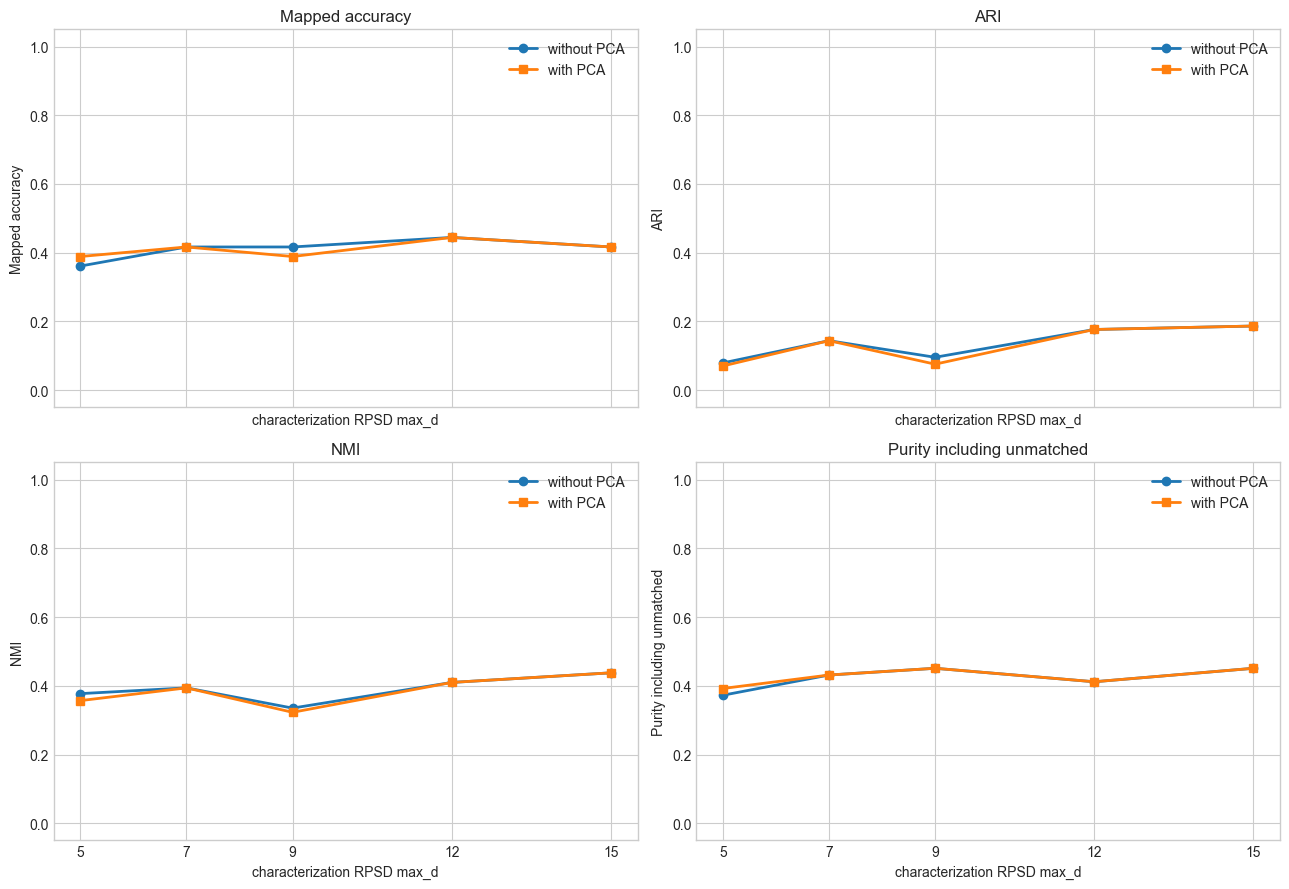

In [6]:
metric_specs = [
    ("mapped_accuracy", "Mapped accuracy"),
    ("ari", "ARI"),
    ("nmi", "NMI"),
    ("purity_including_unmatched", "Purity including unmatched"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ax, (column, title) in zip(axes.ravel(), metric_specs):
    for branch, marker in (("without PCA", "o"), ("with PCA", "s")):
        subset = metrics[metrics["branch"] == branch]
        ax.plot(
            subset["characterization_max_d"],
            subset[column],
            marker=marker,
            linewidth=2,
            label=branch,
        )
    ax.set(
        title=title,
        xlabel="characterization RPSD max_d",
        ylabel=title,
        xticks=CHARACTERIZATION_MAX_DISTANCES,
        ylim=(-0.05, 1.05),
    )
    ax.legend()
plt.tight_layout()
plt.show()

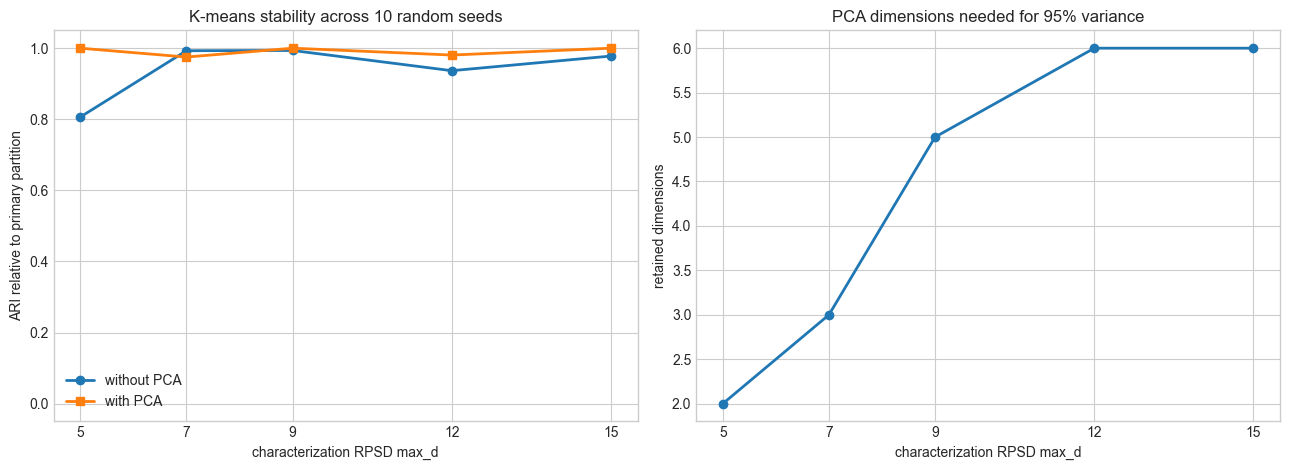

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for branch, marker in (("without PCA", "o"), ("with PCA", "s")):
    subset = metrics[metrics["branch"] == branch]
    axes[0].plot(
        subset["characterization_max_d"],
        subset["mean_stability_ARI"],
        marker=marker,
        linewidth=2,
        label=branch,
    )
axes[0].set(
    title="K-means stability across 10 random seeds",
    xlabel="characterization RPSD max_d",
    ylabel="ARI relative to primary partition",
    xticks=CHARACTERIZATION_MAX_DISTANCES,
    ylim=(-0.05, 1.05),
)
axes[0].legend()

axes[1].plot(
    pca_dimensions["characterization_max_d"],
    pca_dimensions["PCA_dimensions"],
    marker="o",
    linewidth=2,
)
axes[1].set(
    title="PCA dimensions needed for 95% variance",
    xlabel="characterization RPSD max_d",
    ylabel="retained dimensions",
    xticks=CHARACTERIZATION_MAX_DISTANCES,
)
plt.tight_layout()
plt.show()

## 6. Best primary result and confusion matrices

Best setting in each branch


,branch,characterization_max_d,mapped_accuracy,ari,nmi,purity_including_unmatched,mean_stability_ARI,minimum_stability_ARI,mean_seed_mapped_accuracy,std_seed_mapped_accuracy,RPSD_seconds
0,with PCA,12,0.4444,0.1765,0.4098,0.4118,0.9807,0.9678,0.4278,0.0136,1.0591
1,without PCA,12,0.4444,0.1765,0.4098,0.4118,0.9367,0.6897,0.4194,0.0262,1.0591


Overall best primary result: max_d=12, without PCA, accuracy=0.444.


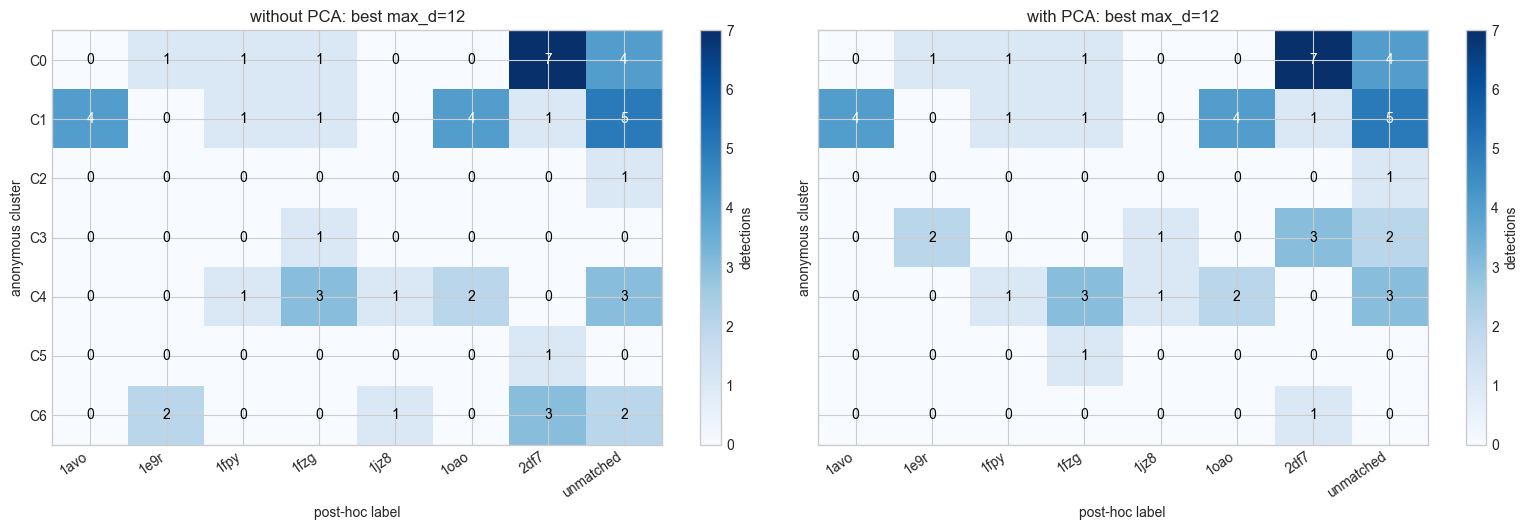

In [8]:
best_row = metrics.sort_values(
    ["mapped_accuracy", "ari", "nmi"],
    ascending=False,
).iloc[0]
best_max_d = int(best_row["characterization_max_d"])
best_branch = str(best_row["branch"])

best_per_branch = (
    metrics.sort_values(["mapped_accuracy", "ari", "nmi"], ascending=False)
    .groupby("branch", as_index=False)
    .first()
)
print("Best setting in each branch")
display(best_per_branch.round(4))
print(
    f"Overall best primary result: max_d={best_max_d}, {best_branch}, "
    f"accuracy={best_row['mapped_accuracy']:.3f}."
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
for ax, branch in zip(axes, ["without PCA", "with PCA"]):
    branch_best = best_per_branch[
        best_per_branch["branch"] == branch
    ].iloc[0]
    max_distance = int(branch_best["characterization_max_d"])
    confusion = confusion_results[(max_distance, branch)]
    image = ax.imshow(confusion, cmap="Blues", aspect="auto")
    threshold = max(confusion.max() / 2, 1)
    for row in range(CLUSTER_COUNT):
        for column in range(len(EVAL_LABELS)):
            value = confusion[row, column]
            ax.text(
                column,
                row,
                str(value),
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )
    ax.set_xticks(
        np.arange(len(EVAL_LABELS)),
        EVAL_LABELS,
        rotation=35,
        ha="right",
    )
    ax.set_yticks(
        np.arange(CLUSTER_COUNT),
        [f"C{k}" for k in range(CLUSTER_COUNT)],
    )
    ax.set(
        title=f"{branch}: best max_d={max_distance}",
        xlabel="post-hoc label",
        ylabel="anonymous cluster",
    )
    fig.colorbar(image, ax=ax, label="detections")
plt.tight_layout()
plt.show()

## 7. Save results

In [9]:
metrics.to_csv(METRICS_CSV, index=False)
assignments.to_csv(ASSIGNMENTS_CSV, index=False)
np.savez_compressed(
    RPSDS_NPZ,
    radial_points=radial_points,
    picks=picks,
    posthoc_labels=posthoc_labels,
    **{
        f"rpsd_maxd_{max_distance}": rpsd_results[max_distance]
        for max_distance in CHARACTERIZATION_MAX_DISTANCES
    },
)

print(f"Saved metrics: {METRICS_CSV.resolve()}")
print(f"Saved assignments: {ASSIGNMENTS_CSV.resolve()}")
print(f"Saved RPSDs: {RPSDS_NPZ.resolve()}")

max_d_summary = (
    metrics.groupby("characterization_max_d")
    .agg(
        best_accuracy=("mapped_accuracy", "max"),
        best_ARI=("ari", "max"),
        best_NMI=("nmi", "max"),
        best_purity=("purity_including_unmatched", "max"),
    )
    .reset_index()
)
display(max_d_summary.round(4))

print(
    "\nInterpretation guardrail: the 51 detections, whitened volume, feature "
    "band, K, and GT labels are identical across the sweep. Only the "
    "characterization ACF support changes. GT determines evaluation metrics "
    "but never enters PCA or K-means."
)

Saved metrics: /Users/moshemaymon/Documents/thesis/tomotwin_cluster_characterization_maxd_metrics.csv
Saved assignments: /Users/moshemaymon/Documents/thesis/tomotwin_cluster_characterization_maxd_assignments.csv
Saved RPSDs: /Users/moshemaymon/Documents/thesis/tomotwin_cluster_characterization_maxd_rpsds.npz


,characterization_max_d,best_accuracy,best_ARI,best_NMI,best_purity
0,5,0.3889,0.0792,0.3772,0.3922
1,7,0.4167,0.1440,0.3940,0.4314
2,9,0.4167,0.0957,0.3351,0.4510
3,12,0.4444,0.1765,0.4098,0.4118
4,15,0.4167,0.1866,0.4378,0.4510



Interpretation guardrail: the 51 detections, whitened volume, feature band, K, and GT labels are identical across the sweep. Only the characterization ACF support changes. GT determines evaluation metrics but never enters PCA or K-means.
